In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/sudan.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [2]:
# Add country column
df["Country"] = "Sudan"

# Convert YEAR + DOY into proper date
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract month
df["Month"] = df["Date"].dt.month

# Check result
df[["YEAR", "DOY", "Date", "Month", "Country"]].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Sudan
1,2015,2,2015-01-02,1,Sudan
2,2015,3,2015-01-03,1,Sudan
3,2015,4,2015-01-04,1,Sudan
4,2015,5,2015-01-05,1,Sudan


In [3]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("Missing values after replacing -999:")
print(df.isna().sum())

print("\n----------------------")

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Drop duplicates if found
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

----------------------
Number of duplicate rows: 0

Dataset shape after removing duplicates:
(4108, 15)


### Missing Values and Duplicate Handling

In the Sudan dataset, all `-999` values were replaced with `NaN` because they represent missing or invalid climate observations. This step was necessary to prevent incorrect statistical calculations during analysis.

After replacing these values, missing values were identified across different climate variables. These missing values were considered during later cleaning steps to improve data quality.

The dataset was also checked for duplicate rows using `df.duplicated().sum()`. Any duplicate records found were removed to avoid repeated observations that could negatively affect the analysis results.

After removing duplicates, the dataset size was updated, ensuring that only unique and valid records were used for further analysis.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [5]:
df.describe(include=[np.number])

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,6.423564
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,3.477046
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,12.000000


### Summary Statistics Interpretation

- Average temperature (**T2M**) = **28.76°C**
- Maximum temperature (**T2M_MAX**) reached **45.96°C**
- Minimum temperature (**T2M_MIN**) dropped to **5.93°C**
- Average temperature range (**T2M_RANGE**) = **15.27°C**
- Maximum rainfall (**PRECTOTCORR**) = **66.49 mm**
- Average humidity (**RH2M**) = **31.36%**
- Maximum wind speed (**WS2M_MAX**) = **9.05 m/s**

### Insight
These statistics show that Sudan generally has a **hot and dry climate**. Rainfall is low for most days, but occasional heavy rainfall occurs during rainy seasons. The large temperature range also shows noticeable variation between daytime and nighttime temperatures.

In [23]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage Per Column:")
print(missing_percentage)

print("\nColumns with more than 5% missing values:")
print(missing_percentage[missing_percentage > 5])

Missing Percentage Per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

Columns with more than 5% missing values:
Series([], dtype: float64)


### Missing Value Analysis

- Missing percentage for all columns = **0%**
- No column has more than **5% missing values**
- No additional missing-value treatment was required

### Insight
After replacing `-999` values and checking the dataset, no missing values remained in Sudan’s climate data. This indicates that the dataset is complete and reliable for further analysis, and no columns were excluded due to missing data issues.

In [7]:
from scipy.stats import zscore

columns_to_check = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = df[columns_to_check].apply(zscore)

outliers = (abs(z_scores) > 3).any(axis=1)

print("Number of outlier rows:")
print(outliers.sum())

Number of outlier rows:
84


### Outlier Detection

- Outliers were detected using Z-scores on key climate variables:
  - T2M
  - T2M_MAX
  - T2M_MIN
  - PRECTOTCORR
  - RH2M
  - WS2M
  - WS2M_MAX

- Number of outlier rows detected = **84**

### Decision
The detected outliers were reviewed carefully. Some extreme values may represent real climate events such as unusually high temperatures, heavy rainfall, or strong winds rather than data errors. Since these values may contain important climate information, they were retained unless they appeared unrealistic.

In [8]:
# Drop rows where more than 30% values are missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill remaining missing values
df = df.ffill()

print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


### Missing Value Treatment

- Rows with more than **30% missing values** were removed from the dataset.
- Forward fill (`ffill`) was applied to handle any remaining missing values in climate variables.
- Remaining missing values after cleaning = **0 for all columns**

### Insight
This cleaning process ensured that incomplete records were removed while preserving useful climate observations. After applying row filtering and forward filling, the Sudan dataset became fully complete and ready for further analysis.

In [9]:
df.to_csv("../data/sudan_clean.csv", index=False)

print("Cleaned sudan dataset exported successfully!")

Cleaned sudan dataset exported successfully!


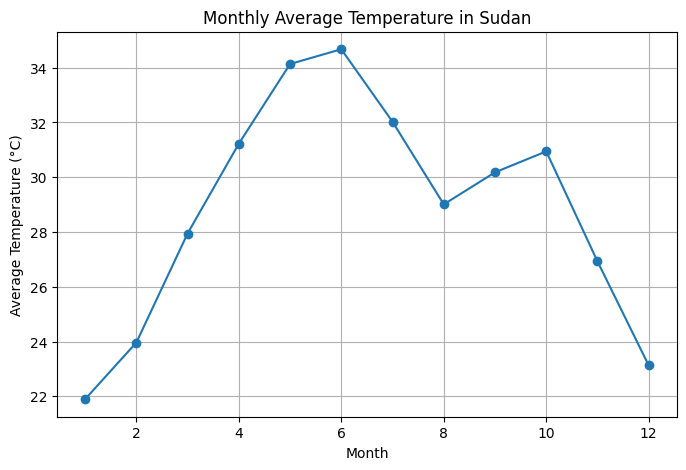

In [10]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature in Sudan")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Analysis

- The hottest month was **June (Month 6)** with an average temperature of approximately **34.7°C**
- The coolest month was **January (Month 1)** with an average temperature of approximately **21.9°C**
- Temperatures gradually increase from January to June
- After June, temperatures begin to decline toward the end of the year

### Insight
The graph shows that Sudan experiences extremely hot conditions during the middle of the year, especially from **May to July**. Lower temperatures are observed at the beginning and end of the year. This indicates clear seasonal temperature variation throughout the year.

In [11]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

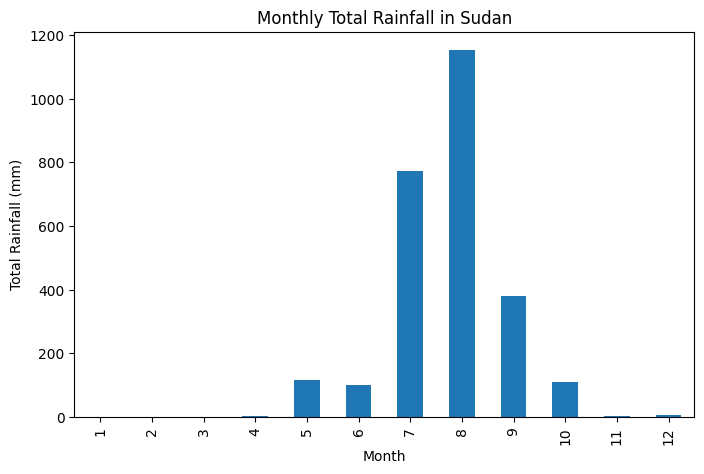

In [12]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall in Sudan")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Monthly Rainfall Trend Analysis

- The highest rainfall occurred in **August (Month 8)** with approximately **1150 mm**
- The second highest rainfall occurred in **July (Month 7)** with approximately **770 mm**
- Rainfall remains very low from **January to April**
- Rainfall starts increasing in **May and June**
- Rainfall decreases again after September

### Insight
The graph shows that Sudan has a clear rainy season during **July and August**, with August being the peak rainfall month. Most other months experience very little rainfall, which confirms that Sudan generally has a dry climate with short seasonal rainfall periods.

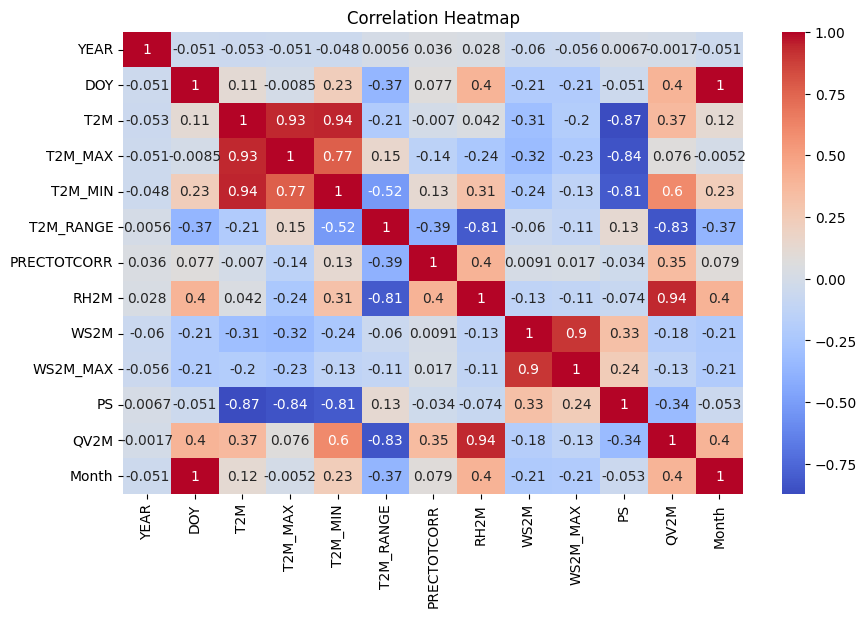

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

Strong correlations identified in the Sudan dataset include:

- **T2M and T2M_MIN = 0.94**
  - This strong positive correlation shows that when average temperature increases, minimum temperature also tends to increase.

- **T2M and T2M_MAX = 0.93**
  - This indicates that higher average temperatures are strongly associated with higher maximum temperatures.

- **RH2M and QV2M = 0.94**
  - This strong positive relationship suggests that higher humidity is associated with increased moisture content in the air.

### Insight
The heatmap shows strong relationships between temperature-related variables and humidity-related variables. These correlations are expected in climate datasets because many weather variables naturally influence each other.

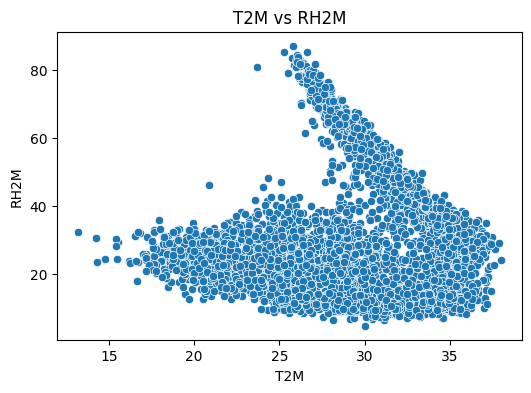

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### Temperature vs Humidity Analysis (T2M vs RH2M)

- The scatter plot shows a generally **negative relationship** between temperature and humidity.
- As temperature increases, humidity tends to decrease in many observations.
- Higher humidity values are mostly concentrated at moderate temperature levels.

### Insight
This pattern suggests that hotter conditions in Sudan are often associated with lower humidity levels, which aligns with Sudan’s generally hot and dry climate conditions.

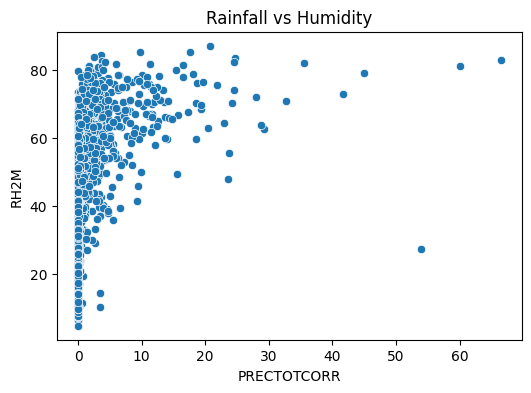

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="PRECTOTCORR", y="RH2M")
plt.title("Rainfall vs Humidity")
plt.show()

### Rainfall vs Humidity Analysis

- Most rainfall values are concentrated at lower precipitation levels.
- Higher humidity levels are commonly associated with rainfall events.
- A few extreme rainfall events are visible as outliers with very high precipitation values.

### Insight
The scatter plot shows that increased rainfall generally occurs when humidity levels are higher. This is expected because wetter atmospheric conditions often lead to rainfall events in Sudan.

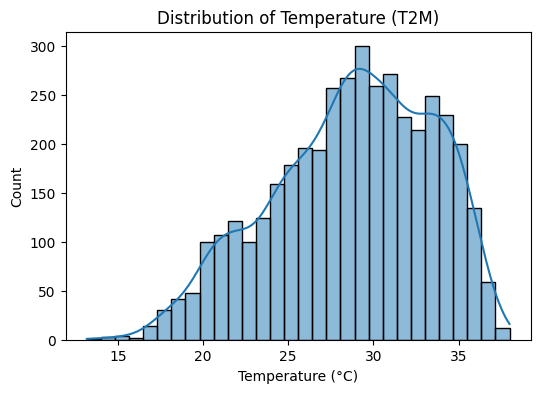

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["T2M"], bins=30, kde=True)
plt.title("Distribution of Temperature (T2M)")
plt.xlabel("Temperature (°C)")
plt.show()

### Temperature Distribution Analysis

- Most temperature values fall between **25°C and 35°C**
- The highest concentration of temperatures is around **29°C to 31°C**
- Very low temperatures below **18°C** occur rarely
- Extremely high temperatures above **36°C** are also less frequent

### Insight
The temperature distribution shows that Sudan experiences consistently warm weather throughout the year. Most days fall within high temperature ranges, confirming Sudan’s generally hot climate.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

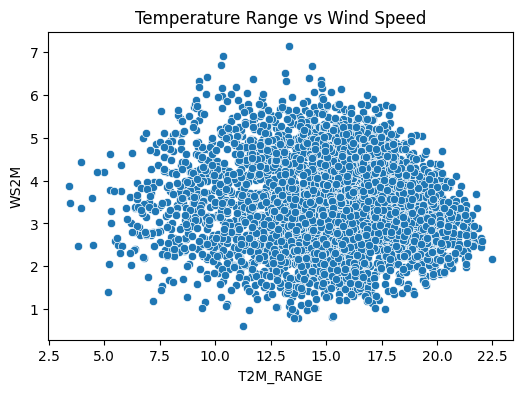

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

### Temperature Range vs Wind Speed Analysis

- The scatter plot shows a weak relationship between temperature range and wind speed.
- Most wind speed values are concentrated between **2 m/s and 5 m/s**.
- Temperature range values are mostly between **10°C and 20°C**.
- There are no strong visible patterns showing that higher temperature ranges directly increase wind speed.

### Insight
This suggests that wind speed in Sudan is not strongly influenced by daily temperature range. Other climate factors may play a larger role in affecting wind conditions.

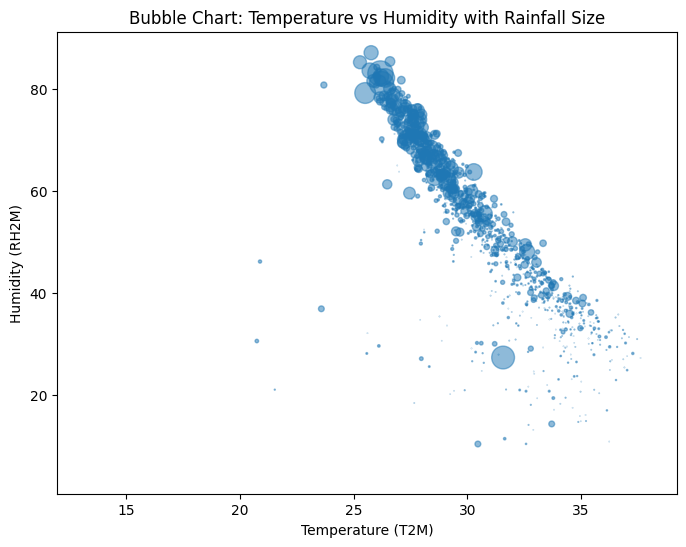

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5,
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity with Rainfall Size")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Analysis: Temperature, Humidity, and Rainfall

- The chart shows a strong negative relationship between temperature and humidity.
- As temperature increases, humidity generally decreases.
- Larger bubbles represent higher rainfall levels.
- Most large rainfall events occur when humidity is high and temperatures are moderate.

### Insight
This suggests that rainfall in Sudan is more likely to occur during periods of higher humidity rather than extremely hot conditions. The chart highlights how temperature, humidity, and rainfall interact in Sudan’s climate patterns.

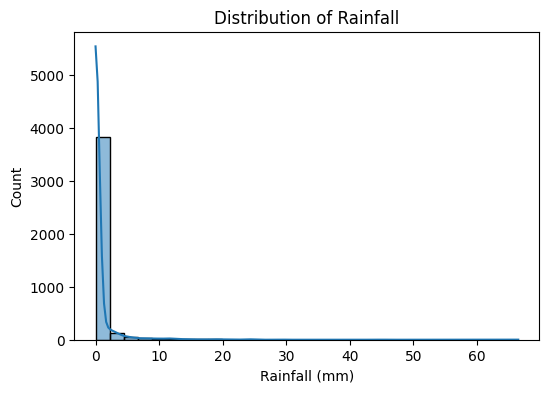

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

Rainfall Distribution Interpretation
Average rainfall is generally low in Sudan.
Most rainfall values are concentrated near 0 mm, showing many dry days.
A few extreme rainfall events reached around 66 mm.
The distribution is right-skewed because heavy rainfall happens only in a few cases.

Overall: Sudan has mostly dry weather with occasional heavy rainfall during rainy seasons.

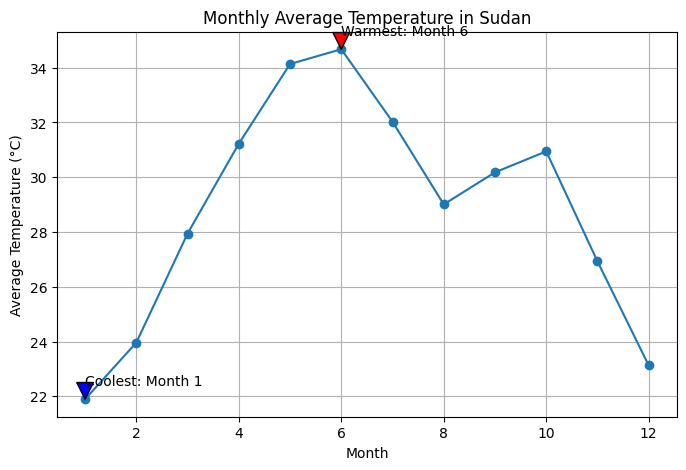

In [21]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")

# Find warmest month
warmest_month = monthly_temp.idxmax()
warmest_temp = monthly_temp.max()

# Find coolest month
coolest_month = monthly_temp.idxmin()
coolest_temp = monthly_temp.min()

# Annotate warmest month
plt.annotate(
    f"Warmest: Month {warmest_month}",
    xy=(warmest_month, warmest_temp),
    xytext=(warmest_month, warmest_temp+0.5),
    arrowprops=dict(facecolor='red')
)

# Annotate coolest month
plt.annotate(
    f"Coolest: Month {coolest_month}",
    xy=(coolest_month, coolest_temp),
    xytext=(coolest_month, coolest_temp+0.5),
    arrowprops=dict(facecolor='blue')
)

plt.title("Monthly Average Temperature in Sudan")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

Monthly Average Temperature Trend in Sudan
Temperature increases from January to June.
June (Month 6) is the warmest month with about 35°C.
January (Month 1) is the coolest month with about 22°C.
Temperature starts decreasing after June with a small rise around October.

Overall: Sudan experiences very hot mid-year temperatures and cooler conditions at the beginning and end of the year.

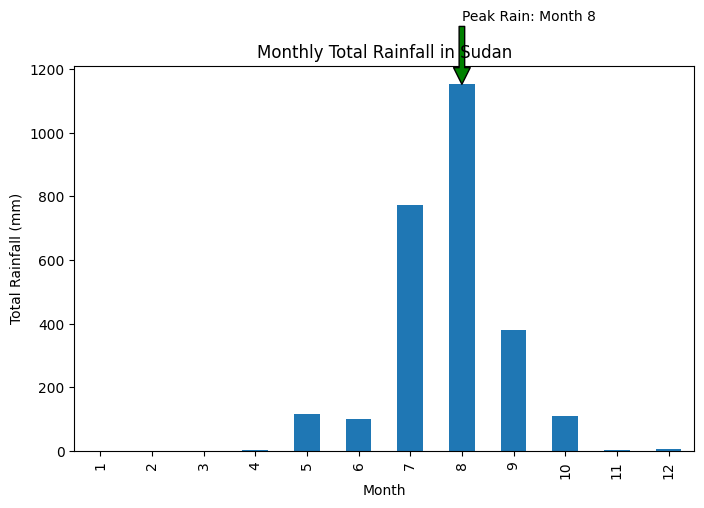

In [22]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")

# Peak rainfall month
peak_month = monthly_rain.idxmax()
peak_rain = monthly_rain.max()

plt.annotate(
    f"Peak Rain: Month {peak_month}",
    xy=(peak_month-1, peak_rain),
    xytext=(peak_month-1, peak_rain+200),
    arrowprops=dict(facecolor='green')
)

plt.title("Monthly Total Rainfall in Sudan")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

Monthly Rainfall Trend Analysis


Sudan receives very little rainfall from January to April.


Rainfall starts increasing in May and June.


August (Month 8) recorded the highest rainfall.


July also shows high rainfall levels.


Rainfall decreases again after September.


Insight
This shows that Sudan has a short rainy season, mainly between July and September, while most months remain dry.

Final EDA Summary

Data Cleaning


Loaded Sudan climate dataset successfully.


Converted YEAR and DOY into a proper Date column.


Created a Month column for monthly analysis.


Replaced invalid -999 values with NaN.


No missing values remained after cleaning.


No duplicate rows were found.


Cleaned dataset was exported successfully.


Descriptive Statistics


Dataset contains 4,108 records.


Average temperature: ~28.76°C


Average humidity: ~31.36%


Average rainfall: ~0.64 mm


Temperature ranges from ~13°C to ~38°C.


Outlier Analysis


Detected 84 outlier rows using the Z-score method.


These likely represent extreme weather conditions such as heavy rainfall or unusual temperature events.


Monthly Trends


Temperature increases from January to June.


The hottest month is June.


Rainfall peaks during July and August.


Most months remain dry with very low rainfall.


Correlation Insights


Temperature and maximum temperature show a strong positive relationship.


Temperature and minimum temperature are strongly correlated.


Humidity and moisture variables also show strong relationships.


Distribution Insights


Temperature follows a relatively normal distribution.


Rainfall is highly right-skewed with many dry days and few heavy rainfall events.


Conclusion
The Sudan climate dataset is clean and suitable for analysis.
Sudan experiences high temperatures throughout the year, a short rainy season, and occasional extreme weather events.